In [47]:
pip install scikit-learn numpy pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv("WineQuality.csv")

In [50]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0


In [51]:
df.isnull().sum()

fixed acidity            0
volatile acidity        18
citric acid             33
residual sugar          43
chlorides               46
free sulfur dioxide     20
total sulfur dioxide    19
density                 82
pH                      33
sulphates               29
alcohol                  5
quality                  2
dtype: int64

In [52]:
df.duplicated().sum()

np.int64(166)

In [53]:
num = df.select_dtypes(include=[np.number])
cat = df.select_dtypes(include=["object"])

In [54]:
def preprocess_data(df, target_col='quality'):
    df_clean = df.copy()
    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else 'Unknown')
    
    id_cols = [col for col in df_clean.columns if 'id' in col.lower()]
    df_clean = df_clean.drop(columns=id_cols)
    
    return df_clean

df_clean = preprocess_data(df)
df_clean.shape

(1699, 5)

In [55]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, classification_report, confusion_matrix, silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

In [56]:
X = df_clean.drop('quality', axis=1)
y = df_clean['quality']

In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [59]:
X_train.shape

(1359, 4)

In [60]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
y_pred_lr = lr_model.predict(X_test)

In [62]:
r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)

In [63]:
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

R² Score: 0.1824
Mean Absolute Error: 0.5652


In [64]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

In [65]:
coef_df.head()

,Feature,Coefficient
3,alcohol,0.370426
2,sulphates,0.138846
0,density,-0.038362
1,pH,-0.090459


In [66]:
coef_df.tail()

,Feature,Coefficient
3,alcohol,0.370426
2,sulphates,0.138846
0,density,-0.038362
1,pH,-0.090459


In [67]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [68]:
y_pred_dt = dt_model.predict(X_test)

In [69]:
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)

In [70]:
print(f"R² Score: {r2_dt:.4f}")
print(f"Mean Absolute Error: {mae_dt:.4f}")

R² Score: 0.1887
Mean Absolute Error: 0.5420


In [71]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

In [72]:
feat_imp

,Feature,Importance
3,alcohol,0.581527
2,sulphates,0.242185
1,pH,0.119119
0,density,0.057170


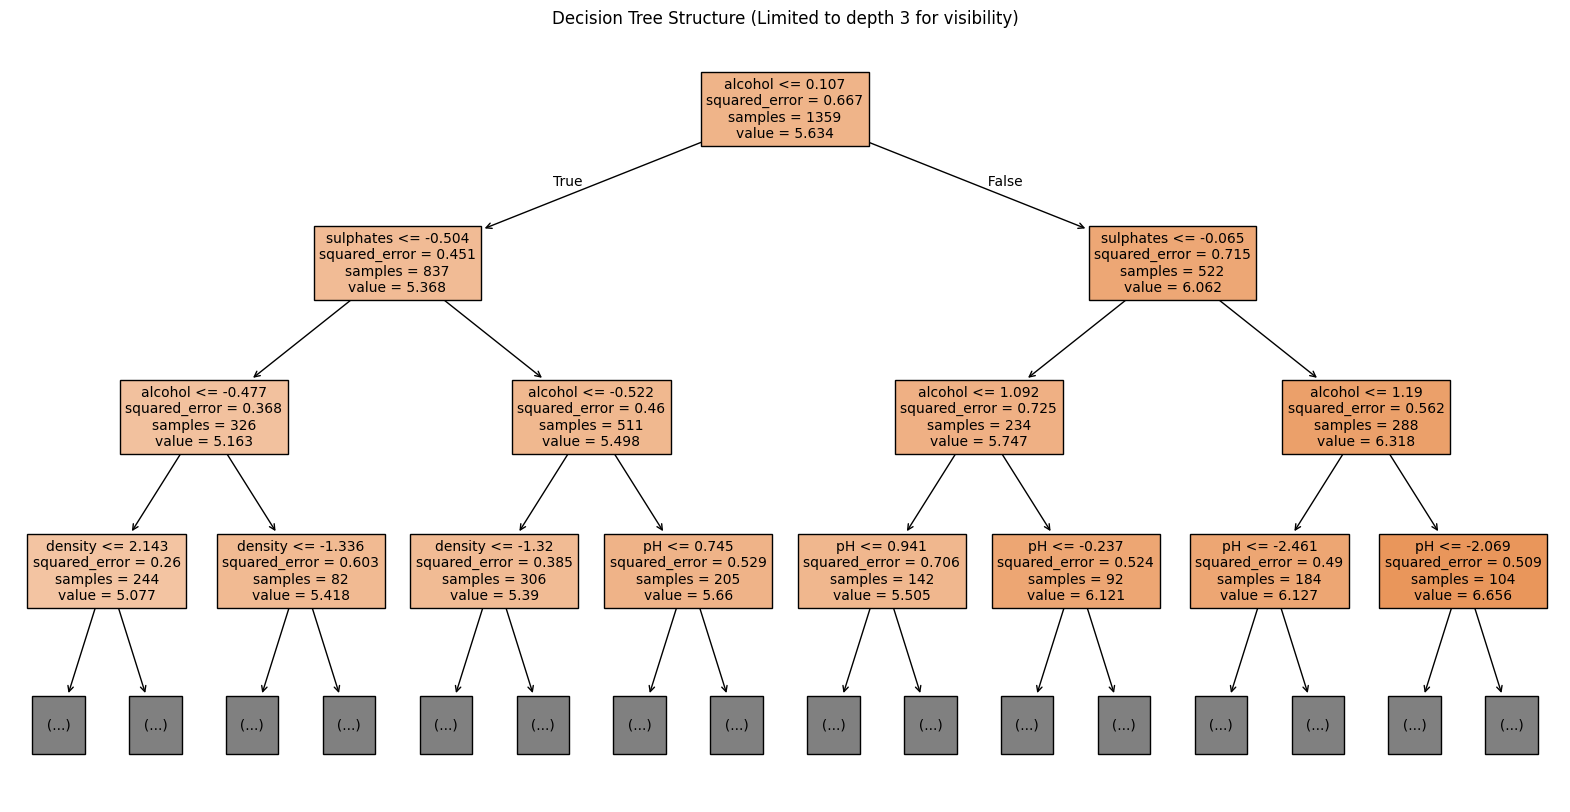

In [82]:
plt.figure(figsize=(20,10))
plot_tree(dt_model, max_depth=3, feature_names=X.columns, filled=True, fontsize=10)
plt.title('Decision Tree Structure (Limited to depth 3 for visibility)')
plt.savefig("Tree_Structure.png")
plt.show()

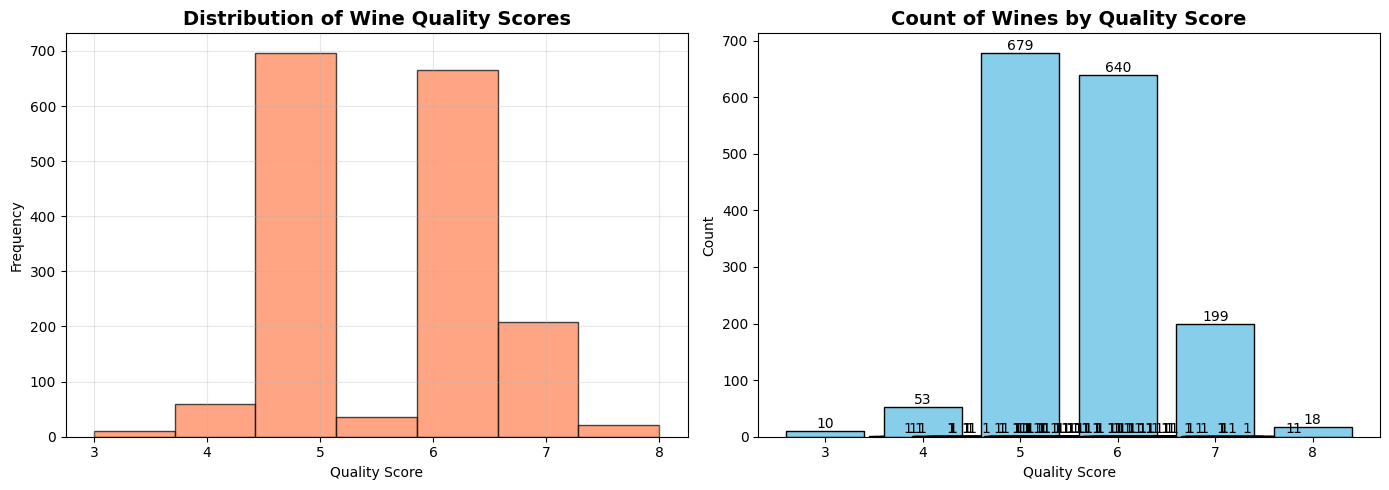

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['quality'], bins=7, edgecolor='black', alpha=0.7, color='coral')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Wine Quality Scores', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

quality_counts = df_clean['quality'].value_counts().sort_index()
bars = axes[1].bar(quality_counts.index, quality_counts.values, color='skyblue', edgecolor='black')
axes[1].set_xlabel('Quality Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Count of Wines by Quality Score', fontsize=14, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig("Count_&_Distribution.png")
plt.show()

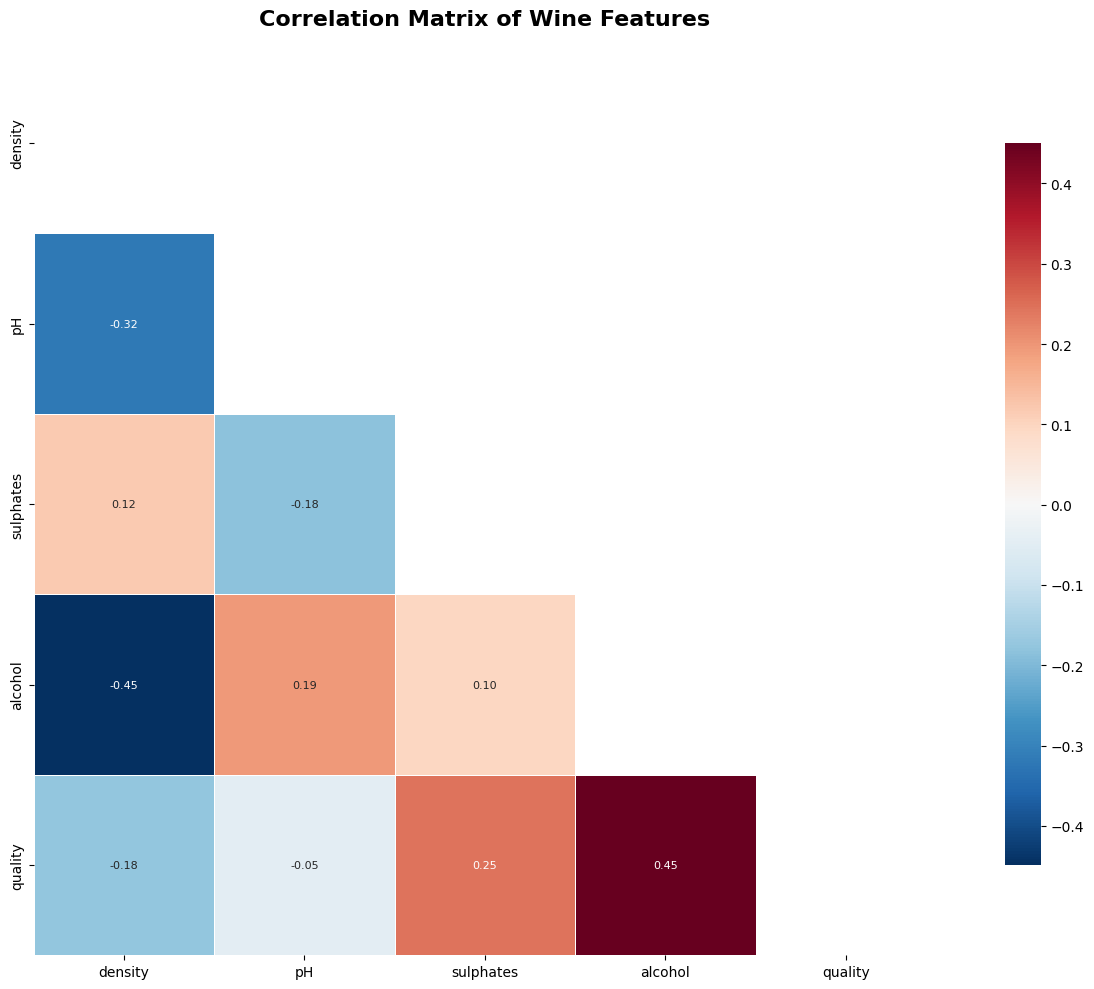

In [83]:
plt.figure(figsize=(14, 10))
correlation_matrix = df_clean.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8})

plt.title('Correlation Matrix of Wine Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("correlation_matrix.png")
plt.show()

In [76]:
from sklearn.ensemble import RandomForestRegressor

In [77]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

models = ['Linear Regression', 'Decision Tree', 'Random Forest']
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf)
]
mae_scores = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_dt),
    mean_absolute_error(y_test, y_pred_rf)
]

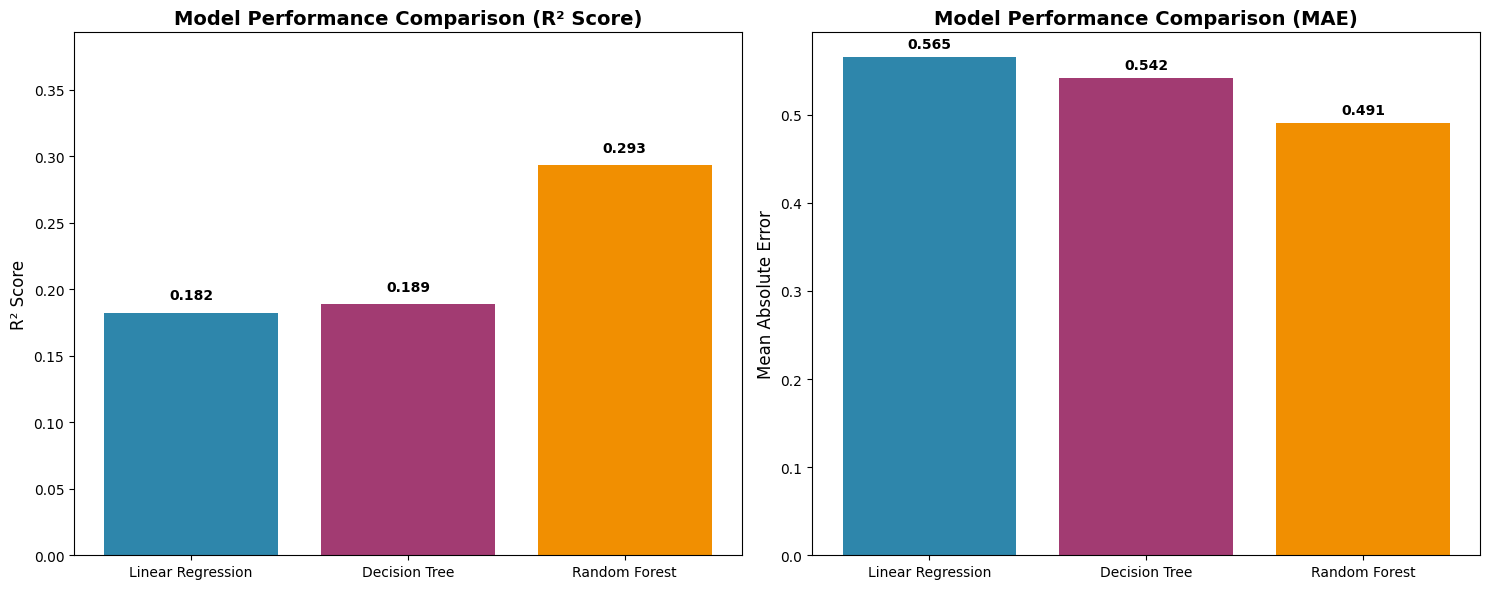

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars1 = axes[0].bar(models, r2_scores, color=['#2E86AB', '#A23B72', '#F18F01'])
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Model Performance Comparison (R² Score)', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, max(r2_scores) + 0.1)
for bar, score in zip(bars1, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.3f}', ha='center', fontweight='bold')

bars2 = axes[1].bar(models, mae_scores, color=['#2E86AB', '#A23B72', '#F18F01'])
axes[1].set_ylabel('Mean Absolute Error', fontsize=12)
axes[1].set_title('Model Performance Comparison (MAE)', fontsize=14, fontweight='bold')
for bar, score in zip(bars2, mae_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("R_sqd_&_MAE.png")
plt.show()

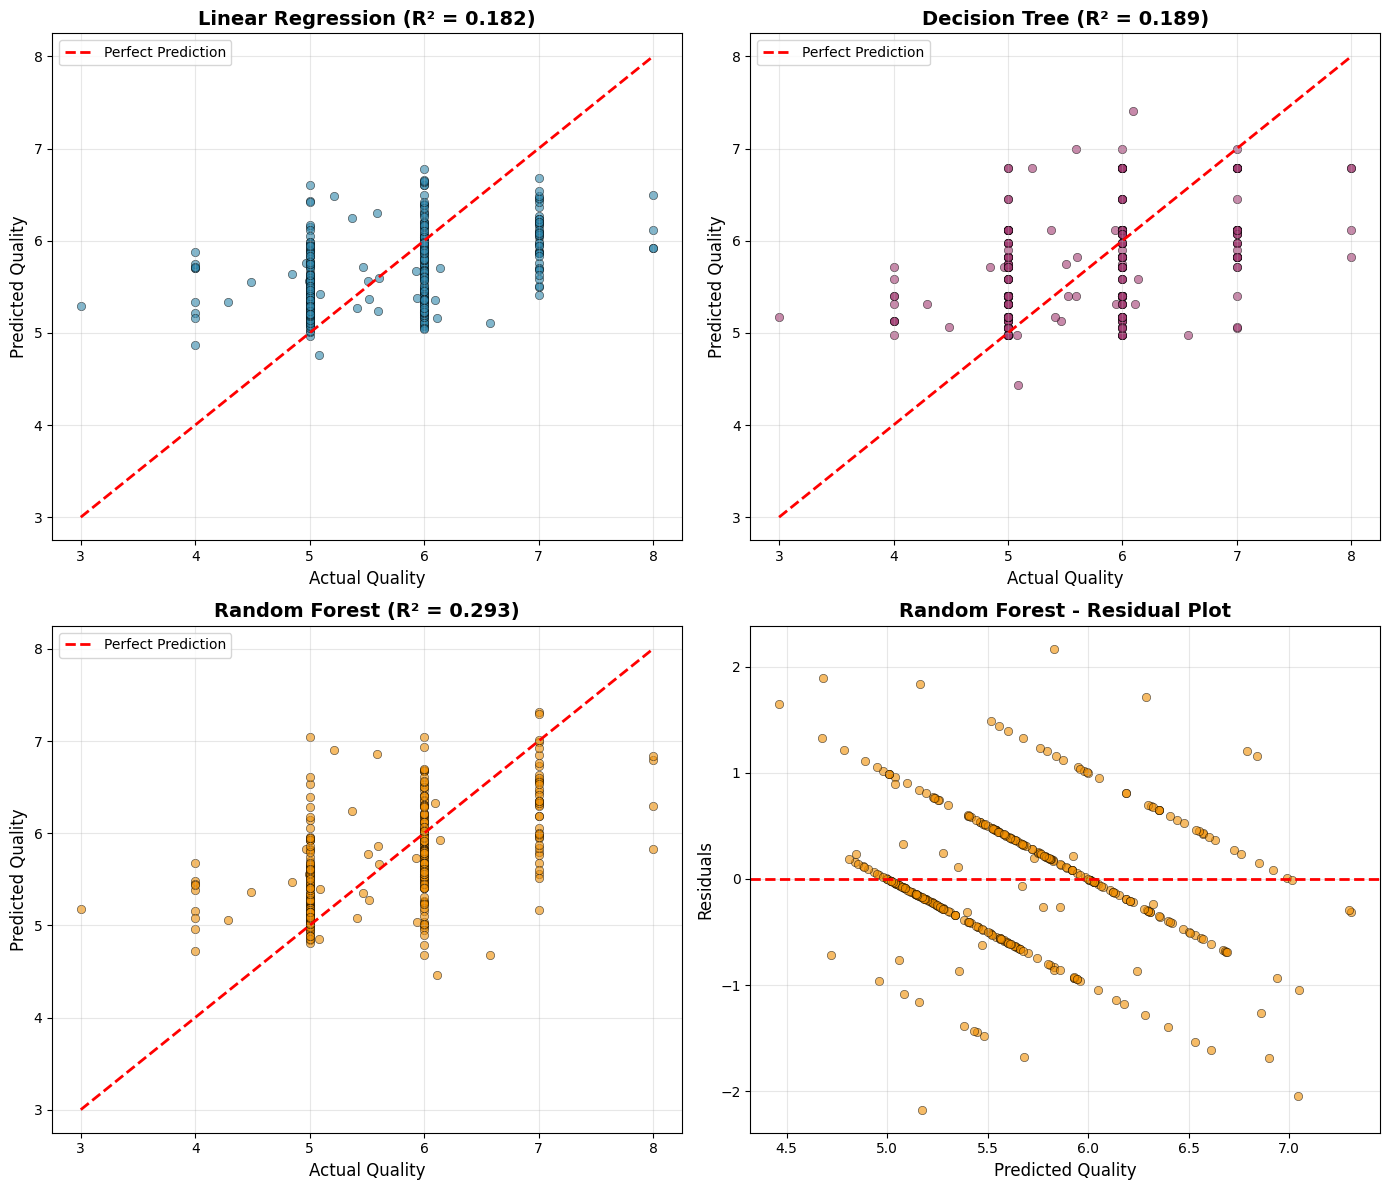

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

axes[0].scatter(y_test, y_pred_lr, alpha=0.6, color='#2E86AB', edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Quality', fontsize=12)
axes[0].set_ylabel('Predicted Quality', fontsize=12)
axes[0].set_title(f'Linear Regression (R² = {r2_scores[0]:.3f})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred_dt, alpha=0.6, color='#A23B72', edgecolors='black', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Quality', fontsize=12)
axes[1].set_ylabel('Predicted Quality', fontsize=12)
axes[1].set_title(f'Decision Tree (R² = {r2_scores[1]:.3f})', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].scatter(y_test, y_pred_rf, alpha=0.6, color='#F18F01', edgecolors='black', linewidth=0.5)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Quality', fontsize=12)
axes[2].set_ylabel('Predicted Quality', fontsize=12)
axes[2].set_title(f'Random Forest (R² = {r2_scores[2]:.3f})', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

residuals = y_test - y_pred_rf
axes[3].scatter(y_pred_rf, residuals, alpha=0.6, color='#F18F01', edgecolors='black', linewidth=0.5)
axes[3].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[3].set_xlabel('Predicted Quality', fontsize=12)
axes[3].set_ylabel('Residuals', fontsize=12)
axes[3].set_title('Random Forest - Residual Plot', fontsize=14, fontweight='bold')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Sactter_Plot.png")
plt.show()